In [54]:
import cv2
import os
data_path="/content/drive/MyDrive/Brain_Tumor"
categories=os.listdir(data_path)
print(categories)

['yes', 'no']


In [55]:
labels=[i for i in range(len(categories))]
print(labels)

[0, 1]


In [56]:
label_dict=dict(zip(categories,labels))
print(label_dict)

{'yes': 0, 'no': 1}


In [57]:
img_size=100                                            # to access the image
data=[]
target=[]

for category in categories:
  folder_path=os.path.join(data_path,category)
  image_names=os.listdir(folder_path)

  for img in image_names:
    img_path=os.path.join(folder_path,img)
    img=cv2.imread(img_path)

    try:
      # REMOVE the grayscale conversion.
      # Convert BGR (OpenCV default) to RGB
      img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      resized = cv2.resize(img_rgb, (img_size, img_size))
      data.append(resized)
      target.append(label_dict[category])

    except Exception as e:
      print("Exception",e)

#This code iterates through each category (e.g., 'yes', 'no') in your categories list. For each category, it goes through all the image files in its corresponding folder. It reads each image using cv2.imread(), converts it to grayscale using cv2.cvtColor(), and then resizes it to a fixed size (img_size x img_size, which is 100x100 pixels in this case). The processed (resized, grayscale) image data is appended to the data list, and its corresponding label (retrieved from label_dict) is appended to the target list. There's also error handling to catch any exceptions that might occur during this process, for example, if an image file is corrupted or unreadable.

In [ ]:
img

In [ ]:
print(len(data))

data[120]

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt    #EDA-->EDA (Exploratory Data Analysis)
plt.figure (figsize=(10,10))
for i in range(4):
  plt.subplot(1,4,i+1)
  plt.imshow(data[i])
  plt.axis('off')
plt.show()

In [61]:
import numpy as np
data = np.array(data)
data.ndim

4

In [62]:
import numpy as np
# Optional: ResNet has its own specific preprocessing, but /255.0 works okay for a basic implementation
data = np.array(data) / 255.0
# Change the last dimension from 1 to 3
data = np.reshape(data, (data.shape[0], img_size, img_size, 3))
target = np.array(target)

In [63]:
from tensorflow.keras.utils import to_categorical
new_target=to_categorical(target)

In [64]:
new_target[200]

array([0., 1.])

In [65]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data,new_target,test_size=0.1,random_state=42)

In [66]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomContrast
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50

# 1. Load the pre-trained ResNet50 model
# include_top=False removes the 1000-class ImageNet output layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(100, 100, 3))

# 2. Freeze the base model's weights
base_model.trainable = False

# 3. Build your new architecture
model = Sequential([
    Input(shape=(100, 100, 3)),

    # Data Augmentation Block (Keep this!)
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomTranslation(height_factor=0.08, width_factor=0.08),
    RandomZoom(0.08),
    RandomContrast(0.15),

    # The new Feature Extractor
    base_model,

    # Compress the features (replaces Flatten)
    GlobalAveragePooling2D(),

    # Your Classification Head
    Dropout(0.5),
    Dense(50, activation='relu'),
    Dense(2, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 100, 100, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_3            │ (None, 100, 100, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_3               │ (None, 100, 100, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │       102,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,690,264 (90.37 MB)

 Trainable params: 102,552 (400.59 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [67]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 496ms/step - accuracy: 0.5639 - loss: 0.7434 - val_accuracy: 0.5769 - val_loss: 0.7073
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.6079 - loss: 0.7054 - val_accuracy: 0.5385 - val_loss: 0.6809
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5198 - loss: 0.8006 - val_accuracy: 0.5769 - val_loss: 0.6701
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.6167 - loss: 0.6978 - val_accuracy: 0.6538 - val_loss: 0.6186
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4758 - loss: 0.7652 - val_accuracy: 0.5769 - val_loss: 0.6247
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6344 - loss: 0.6909 - val_accuracy: 0.6538 - val_loss: 0.5967
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5507 - loss: 0.7105 - val_accuracy: 0.5769 - val_loss: 0.6121
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6608 - loss: 0.6715 - val_accuracy: 0.5769 - val_loss: 0.616

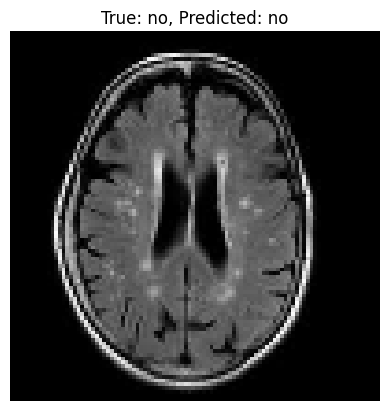

In [68]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

r = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    callbacks=[early_stop]
)

# Get one image from the test set
import numpy as np
import matplotlib.pyplot as plt

image_index = 0 # You can change this index to view different images
single_image = x_test[image_index]
true_label = np.argmax(y_test[image_index])

# The model expects a batch of images, so we add a dimension
reshaped_image = np.expand_dims(single_image, axis=0)

# Make a prediction
prediction_probabilities = model.predict(reshaped_image)
predicted_label = np.argmax(prediction_probabilities)

# Map back to category names (assuming 'yes' is 0, 'no' is 1)
reverse_label_dict = {v: k for k, v in label_dict.items()}
predicted_category = reverse_label_dict[predicted_label]
true_category = reverse_label_dict[true_label]

print(f"Predicted Category: {predicted_category}")
print(f"True Category: {true_category}")

if predicted_label == true_label:
    print("Prediction: Accurate")
else:
    print("Prediction: Incorrect")

# Display the image
plt.imshow(single_image)
plt.title(f"True: {true_category}, Predicted: {predicted_category}")
plt.axis('off')
plt.show()

In [70]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6538 - loss: 0.5967
Test Loss: 0.5967
Test Accuracy: 0.6538
